In [ ]:
#importing libraries
import ast 
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)


In [45]:
#filtering the data to only Data Analyst from the Uk
df_DA_US = df[(df['job_title_short']== "Data Analyst") & (df['job_country']== "United States")].copy()

In [46]:
df_plot= df_DA_US['job_location'].value_counts().head(10).to_frame()

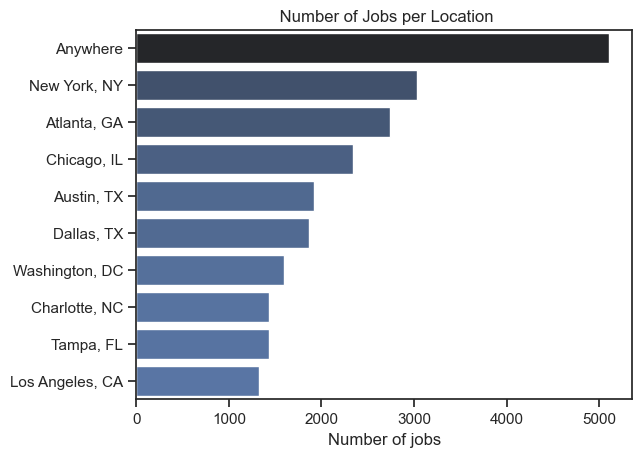

In [47]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend= False)
sns.despine
plt.title(' Number of Jobs per Location')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()

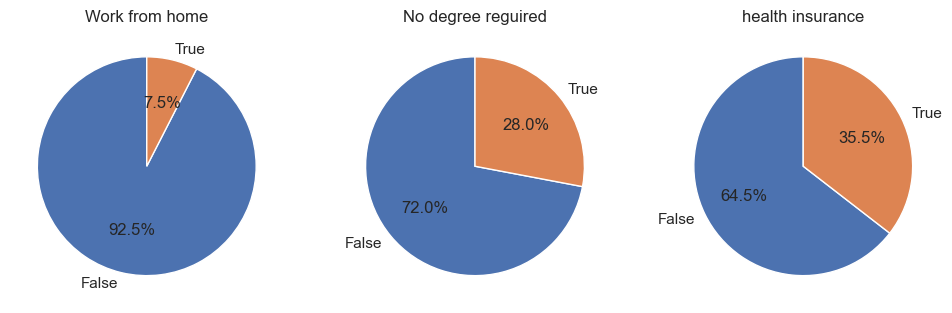

In [48]:


job_dict= {'job_work_from_home':'Work from home',
      'job_no_degree_mention': 'No degree reguired',
      'job_health_insurance': 'health insurance'
      }


fig, ax= plt.subplots(1,3)
fig.set_size_inches(12,5)


for i, (column, title)in enumerate(job_dict.items()):
    ax[i].pie(df_DA_US[column].value_counts(),labels=['False','True'],startangle=90, autopct= '%1.1f%%')
    ax[i].set_title(title)



plt.show()


In [51]:
df_plot= df_DA_US['company_name'].value_counts().head(10).to_frame()

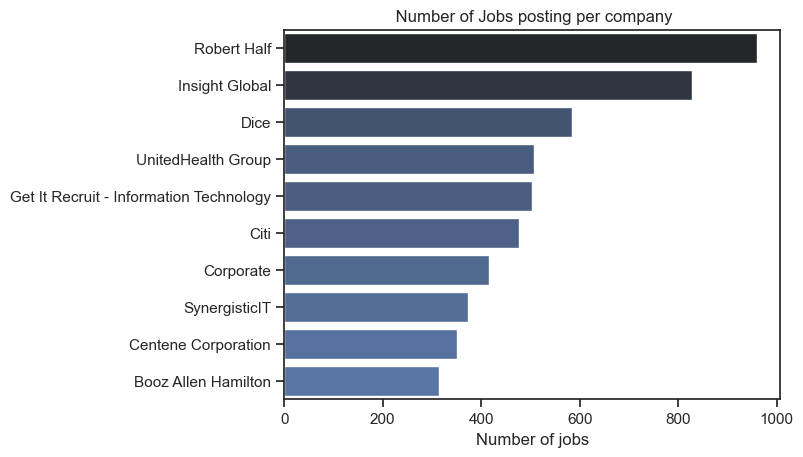

In [52]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend= False)
sns.despine
plt.title(' Number of Jobs posting per company')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()